# Parte 4 — Experimento B: BERTweet
### Workshop: Clasificación de Emociones en Twitter

**Modelo:** `vinai/bertweet-base`  
**Pre-entrenamiento:** 850M tweets en inglés  
**Tokenizador:** BPE entrenado sobre texto de Twitter

BERTweet tiene la misma arquitectura que BERT-base (12 capas, 768 dimensiones, ~110M parámetros), pero fue pre-entrenado desde cero sobre tweets.

> **Nota sobre `normalization=True`:** el tokenizador normaliza las URLs a `HTTPURL` y los @mentions a `@USER` antes de tokenizar, replicando el preprocesamiento usado durante el pre-entrenamiento.

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [1]:
%run /teamspace/studios/this_studio/SI7011-DeepLearning/Lecture06/notebooks/excercise/tweeteval-part-2-pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


## Configuración del experimento

In [2]:
MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO          = "jezapataf/tweeteval-emotion-bertweet"  # <-- cambia esto
LR               = 2e-5

### 📝 TODO 4.1 — Tokenizar el dataset con BERTweet

Importante: carga el tokenizador con `normalization=True`.

In [3]:
# TODO 4.1 ── Tokenizar con BERTweet
# ─────────────────────────────────────────────────────────────────────────────
# Carga el tokenizador con normalization=True y tokeniza el dataset
# Guarda el resultado en ds_bertweet

# YOUR CODE HERE

tok_bertweet = AutoTokenizer.from_pretrained(
    MODEL_CHECKPOINT,
    normalization=True
)

ds_bertweet = make_tokenized_dataset(
    tok_bertweet,
    max_length=MAX_LENGTH
)

print(ds_bertweet)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


### 📝 TODO 4.2 — Cargar el modelo BERTweet

Mismo procedimiento que con DistilBERT pero con `MODEL_CHECKPOINT`. Imprime el número de parámetros y compáralo con DistilBERT.

In [4]:
# TODO 4.2 ── Cargar BERTweet para clasificación
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
model_bertweet = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

### 📝 TODO 4.3 — Entrenar y evaluar BERTweet

Repite el mismo proceso del TODO 3.3 con el modelo y dataset de BERTweet.

**Pregunta:** ¿necesitarías cambiar el learning rate para BERTweet vs DistilBERT? ¿Por qué sí o por qué no?
No necesariamente cambiaría el learning rate al inicio. Usaría el mismo LR que en DistilBERT para tener una comparación justa entre modelos.

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.881737,0.745399,0.700819,0.783422
2,0.591722,0.579778,0.759155,0.823529
3,0.438596,0.561434,0.756524,0.807487
4,0.347441,0.540629,0.769629,0.820856
5,0.271380,0.551581,0.773578,0.823529


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

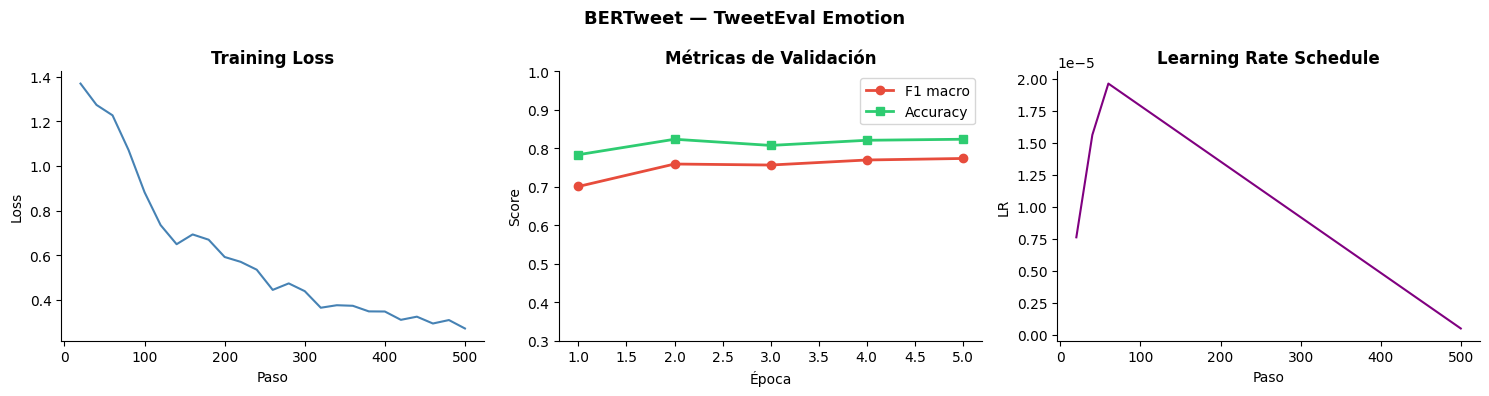


  Test — BERTweet
              precision    recall  f1-score   support

       anger     0.8750    0.8907    0.8828       558
         joy     0.8551    0.8408    0.8479       358
    optimism     0.7619    0.6504    0.7018       123
     sadness     0.7929    0.8220    0.8072       382

    accuracy                         0.8388      1421
   macro avg     0.8212    0.8010    0.8099      1421
weighted avg     0.8381    0.8388    0.8380      1421



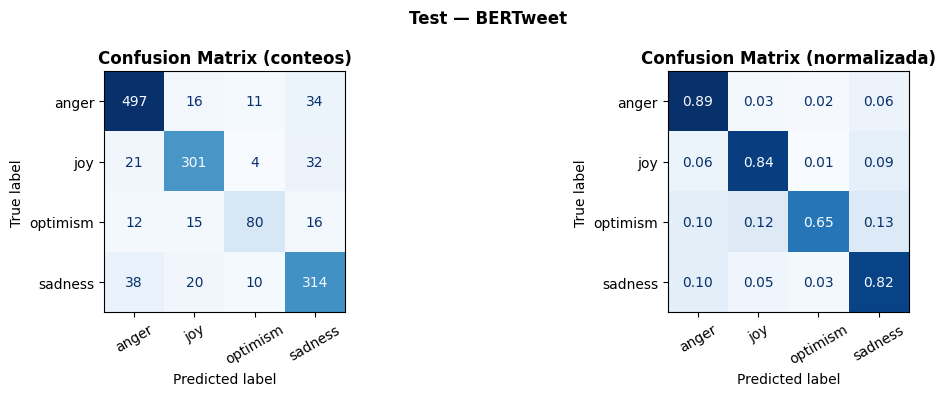

{'test_loss': 0.5256494283676147,
 'test_f1_macro': 0.8099026309226955,
 'test_accuracy': 0.8388458831808585,
 'test_runtime': 1.0763,
 'test_samples_per_second': 1320.242,
 'test_steps_per_second': 41.809}

In [5]:
# TODO 4.3 ── Entrenamiento de BERTweet
# ─────────────────────────────────────────────────────────────────────────────
# Guarda los resultados en metrics_bertweet y el trainer en trainer_bertweet

trainer_bertweet = make_trainer(
    model_bertweet,
    tok_bertweet,
    ds_bertweet,
    output_dir="./checkpoints/bertweet",
    lr=LR
)

trainer_bertweet.train()

plot_training_curves(
    trainer_bertweet,
    title="BERTweet — TweetEval Emotion"
)

metrics_bertweet = full_evaluation(
    trainer_bertweet,
    ds_bertweet["test"],
    model_name="BERTweet"
)

metrics_bertweet

## Push to Hub

In [6]:
trainer_bertweet.push_to_hub(
    commit_message="BERTweet fine-tuning — TweetEval emotion"
)

print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Modelo publicado en: https://huggingface.co/jezapataf/tweeteval-emotion-bertweet
